In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 150


In [2]:
import pandas as pd, networkx as nx

nodes = pd.read_csv("../data/week1_nodes.tsv", sep="\t", comment="#",
                    quoting=3)
edges = pd.read_csv("../data/week1_edges.tsv", sep="\t",
                    comment="#", names=["source", "target"])

G = nx.DiGraph()
G.add_nodes_from(nodes.node_id)
G.add_edges_from(edges.itertuples(index=False))
G_u = G.to_undirected()

print(f"G: {G.number_of_nodes()} nodes, {G.number_of_edges()} directed edges")

G: 303 nodes, 1784 directed edges


## The obvious suspects

We are not trying to prove the obvious. We are testing whether the most famous names really sit at the center of the network by more than one definition of centrality.

The next step is to compare how characters rank on in-degree, out-degree, and undirected degree. This gives us the "usual suspects" before we look for the weird cases that do not fit the expectation.


In [3]:
node_metrics = pd.DataFrame({
    "character": list(G.nodes()),
    "in_degree": [G.in_degree(node) for node in G.nodes()],
    "out_degree": [G.out_degree(node) for node in G.nodes()],
    "undirected_degree": [G_u.degree(node) for node in G.nodes()],
})

node_metrics["total_directed_degree"] = node_metrics["in_degree"] + node_metrics["out_degree"]
node_metrics["link_balance"] = node_metrics["in_degree"] - node_metrics["out_degree"]
node_metrics["incoming_share"] = np.where(
    node_metrics["total_directed_degree"] > 0,
    node_metrics["in_degree"] / node_metrics["total_directed_degree"],
    0,
)

node_metrics["in_rank"] = node_metrics["in_degree"].rank(method="min", ascending=False).astype(int)
node_metrics["out_rank"] = node_metrics["out_degree"].rank(method="min", ascending=False).astype(int)
node_metrics["undirected_rank"] = node_metrics["undirected_degree"].rank(method="min", ascending=False).astype(int)

usual_suspects = node_metrics.sort_values(
    ["undirected_degree", "in_degree", "out_degree"], ascending=False
)
print(usual_suspects[["character", "in_degree", "out_degree", "undirected_degree"]].head(15).to_string(index=False))

                    character  in_degree  out_degree  undirected_degree
                   Spider-Man        106           9                106
                         Hulk         64          10                 65
        Wolverine_(character)         60          17                 63
               Doctor_Strange         50          17                 57
                     Deadpool         33          19                 41
                     She-Hulk         29          20                 37
                Scarlet_Witch         28          14                 32
                Phoenix_Force         24          17                 32
    Black_Panther_(character)         27          11                 31
            Venom_(character)         17          21                 29
                    Luke_Cage         25           9                 28
    Black_Cat_(Marvel_Comics)         21          14                 28
Cloak_and_Dagger_(characters)         11          24            

## The first question: who is the most connected?

We begin with undirected degree because it is the simplest way to answer, "how many distinct neighbors does this character have?"

Spider-Man may dominate this view — that is not a surprise. The more interesting question is whether the same characters dominate every notion of importance, or whether different kinds of importance point to different superheroes.


                character  undirected_degree
               Spider-Man                106
                     Hulk                 65
    Wolverine_(character)                 63
           Doctor_Strange                 57
                 Deadpool                 41
                 She-Hulk                 37
            Phoenix_Force                 32
            Scarlet_Witch                 32
Black_Panther_(character)                 31
        Venom_(character)                 29


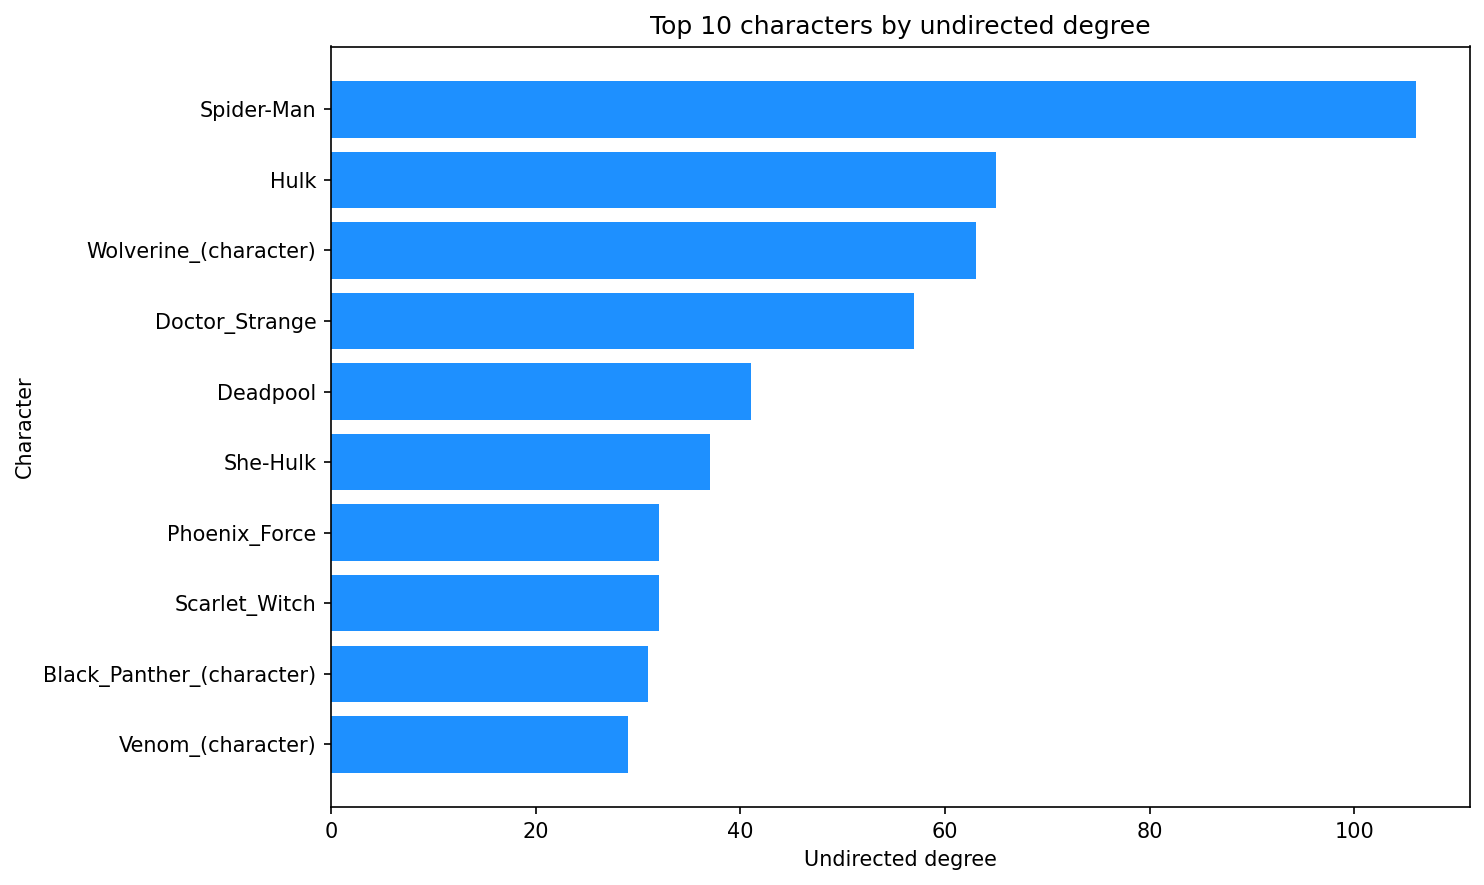

In [4]:
top_undirected = node_metrics.sort_values("undirected_degree", ascending=False).head(10)

print(top_undirected[["character", "undirected_degree"]].to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(
    top_undirected["character"][::-1],
    top_undirected["undirected_degree"][::-1],
    color="dodgerblue",
)
plt.title("Top 10 characters by undirected degree")
plt.xlabel("Undirected degree")
plt.ylabel("Character")
plt.tight_layout()
plt.show()

## Being talked about vs doing the talking

In a directed network, there is an important difference between being referenced by many others and referencing many others in turn.

- in-degree = how many pages point to this superhero
- out-degree = how many pages this superhero points to
- undirected degree = how many distinct neighbors in total

These are related, but they are not the same thing.


Top by in-degree:
                character  in_degree
               Spider-Man        106
                     Hulk         64
    Wolverine_(character)         60
           Doctor_Strange         50
                 Deadpool         33
                 She-Hulk         29
            Scarlet_Witch         28
Black_Panther_(character)         27
  Cyclops_(Marvel_Comics)         26
                Luke_Cage         25

Top by out-degree:
                    character  out_degree
               Betsy_Braddock          28
Cloak_and_Dagger_(characters)          24
                 Adam_Warlock          22
            Venom_(character)          21
                     She-Hulk          20
                   U.S._Agent          20
               Rachel_Summers          19
                     Deadpool          19
                     Noh-Varr          18
                   Emma_Frost          17


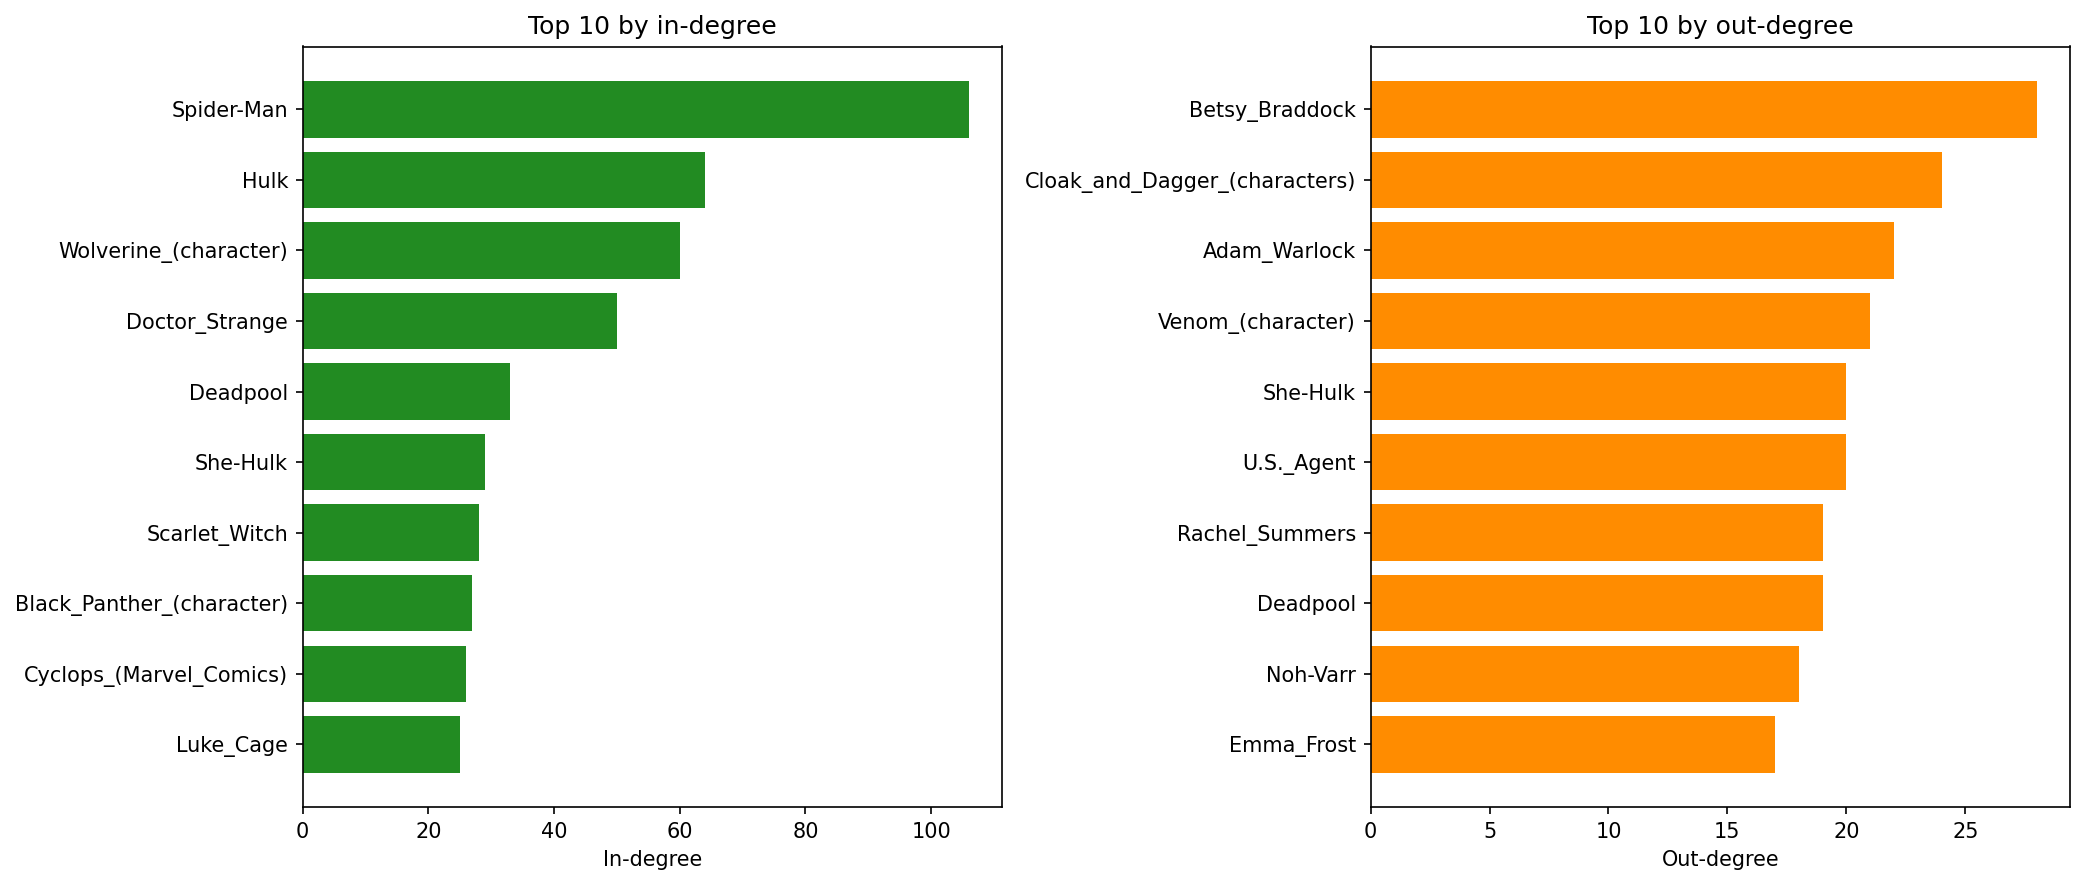


Comparison of top-ranked characters:
                    character  in_degree  out_degree  undirected_degree
                   Spider-Man        106           9                106
                         Hulk         64          10                 65
        Wolverine_(character)         60          17                 63
               Doctor_Strange         50          17                 57
                     Deadpool         33          19                 41
                     She-Hulk         29          20                 37
                Scarlet_Witch         28          14                 32
    Black_Panther_(character)         27          11                 31
      Cyclops_(Marvel_Comics)         26          11                 26
                    Luke_Cage         25           9                 28
               Betsy_Braddock          7          28                 28
Cloak_and_Dagger_(characters)         11          24                 28
                 Adam_Warl

In [5]:
top_in = node_metrics.sort_values("in_degree", ascending=False).head(10)
top_out = node_metrics.sort_values("out_degree", ascending=False).head(10)

print("Top by in-degree:")
print(top_in[["character", "in_degree"]].to_string(index=False))
print("\nTop by out-degree:")
print(top_out[["character", "out_degree"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_in["character"][::-1], top_in["in_degree"][::-1], color="forestgreen")
axes[0].set_title("Top 10 by in-degree")
axes[0].set_xlabel("In-degree")
axes[1].barh(top_out["character"][::-1], top_out["out_degree"][::-1], color="darkorange")
axes[1].set_title("Top 10 by out-degree")
axes[1].set_xlabel("Out-degree")
plt.tight_layout()
plt.show()

rank_union = pd.concat([
    top_in[["character", "in_degree", "out_degree", "undirected_degree"]],
    top_out[["character", "in_degree", "out_degree", "undirected_degree"]],
    top_undirected[["character", "in_degree", "out_degree", "undirected_degree"]],
]).drop_duplicates("character")
print("\nComparison of top-ranked characters:")
print(rank_union.to_string(index=False))

## Not all Marvel hubs behave the same way

The next question is not "who is central?" but "what is the pattern of centrality?" Some characters receive many links. Some send many links. Some do both. Others barely participate in this network at all.

We create a simple 'link personality' for each character by looking at how much it receives versus emits.


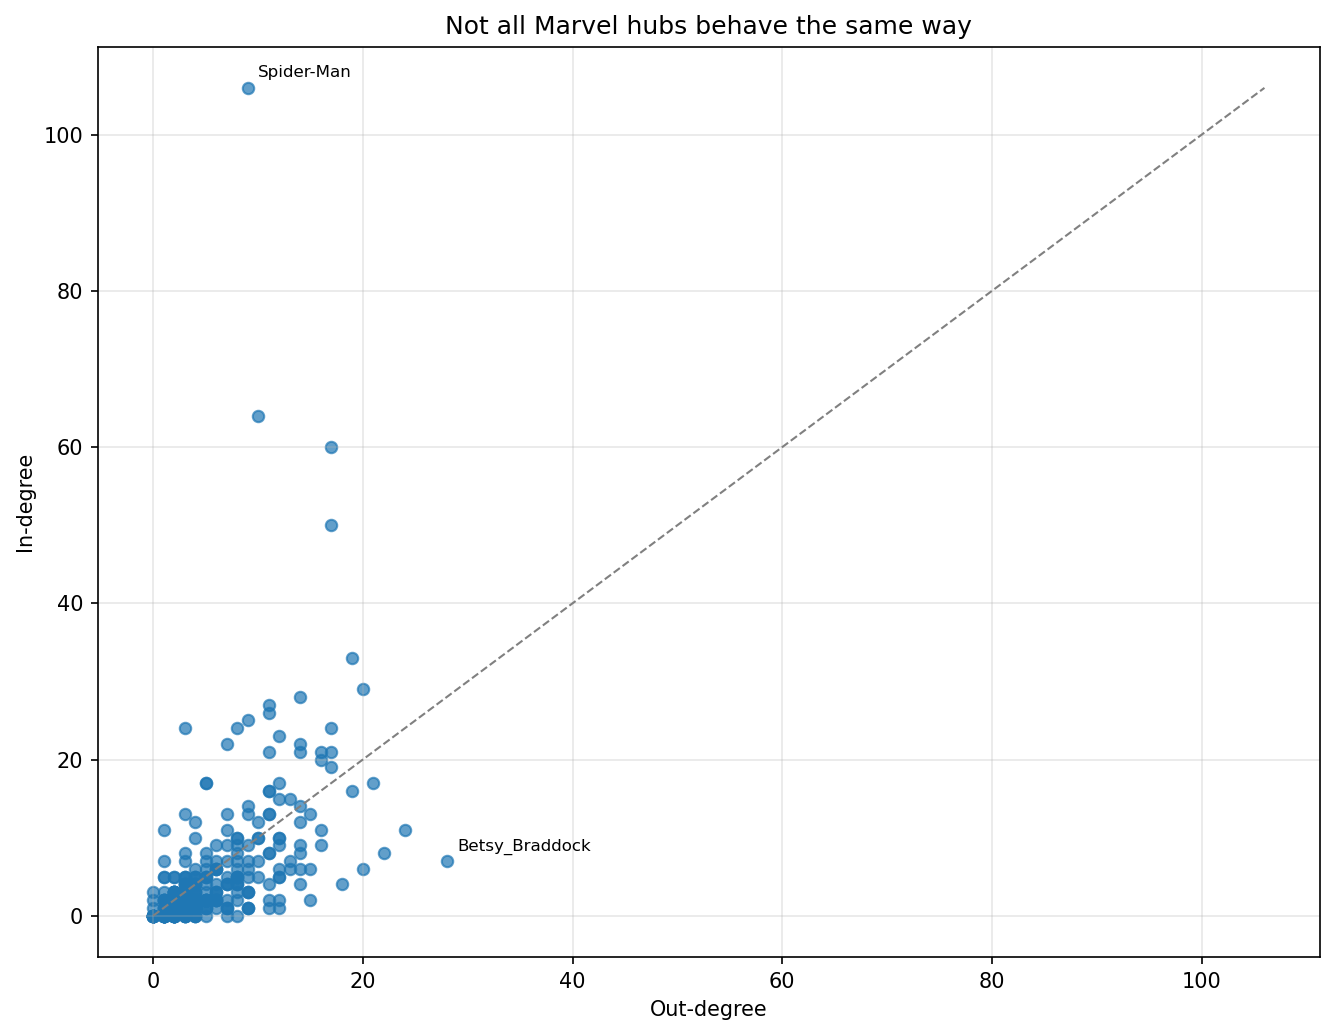

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(node_metrics["out_degree"], node_metrics["in_degree"], alpha=0.7, s=30)

max_degree = max(node_metrics["in_degree"].max(), node_metrics["out_degree"].max())
ax.plot([0, max_degree], [0, max_degree], "--", color="gray", linewidth=1)

interesting = pd.concat([
    node_metrics.nlargest(1, "in_degree"),
    node_metrics.nlargest(1, "out_degree"),
    node_metrics.nlargest(1, "link_balance"),
    node_metrics.nsmallest(1, "link_balance"),
]).drop_duplicates("character")
for _, row in interesting.iterrows():
    ax.annotate(row["character"], (row["out_degree"], row["in_degree"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.set_title("Not all Marvel hubs behave the same way")
ax.set_xlabel("Out-degree")
ax.set_ylabel("In-degree")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Define network archetypes

The data suggest that not all hub-like characters are alike. We can classify them by how much they receive versus emit.

To keep the rules transparent, we use percentile-based thresholds rather than arbitrary fixed degree cutoffs. A character is extreme only if it sits in the top or bottom portion of the observed distribution.

- Celebrities: high in-degree, relatively low out-degree
- Connectors: high out-degree relative to in-degree
- Socialites: high in-degree and high out-degree
- Outsiders: very few or zero links inside this network


In [7]:
in_q80 = node_metrics["in_degree"].quantile(0.80)
out_q80 = node_metrics["out_degree"].quantile(0.80)
total_q80 = node_metrics["total_directed_degree"].quantile(0.80)
low_q20 = node_metrics["total_directed_degree"].quantile(0.20)

node_metrics["archetype"] = "Outsiders"
node_metrics.loc[
    (node_metrics["total_directed_degree"] >= total_q80)
    & (node_metrics["in_degree"] >= in_q80)
    & (node_metrics["out_degree"] >= out_q80),
    "archetype",
] = "Socialites"
node_metrics.loc[
    (node_metrics["out_degree"] >= out_q80) & (node_metrics["in_degree"] < in_q80),
    "archetype",
] = "Connectors"
node_metrics.loc[
    (node_metrics["in_degree"] >= in_q80) & (node_metrics["out_degree"] < out_q80),
    "archetype",
] = "Celebrities"
node_metrics.loc[
    (node_metrics["total_directed_degree"] <= low_q20)
    & (node_metrics["in_degree"] <= 1)
    & (node_metrics["out_degree"] <= 1),
    "archetype",
] = "Outsiders"

for archetype in ["Celebrities", "Connectors", "Socialites", "Outsiders"]:
    examples = node_metrics[node_metrics["archetype"] == archetype].sort_values(
        "total_directed_degree", ascending=False
    ).head(5)
    print(f"\n{archetype} examples:")
    print(examples[["character", "in_degree", "out_degree", "total_directed_degree"]].to_string(index=False))


Celebrities examples:
                     character  in_degree  out_degree  total_directed_degree
                    Spider-Man        106           9                    115
                     Luke_Cage         25           9                     34
                      Hank_Pym         24           8                     32
Black_Widow_(Natasha_Romanova)         22           7                     29
            Quasar_(character)         24           3                     27

Connectors examples:
       character  in_degree  out_degree  total_directed_degree
  Betsy_Braddock          7          28                     35
      U.S._Agent          6          20                     26
        Noh-Varr          4          18                     22
        Gwenpool          6          15                     21
Captain_Universe          6          14                     20

Socialites examples:
            character  in_degree  out_degree  total_directed_degree
Wolverine_(character)    

## Hidden celebrities

Some characters become famous in the network not because they send out many links, but because many other pages point toward them.

These are the characters who receive attention without necessarily being active connectors themselves.


In [8]:
hidden_celebrities = node_metrics.assign(
    in_minus_out=node_metrics["in_degree"] - node_metrics["out_degree"]
).sort_values("in_minus_out", ascending=False).head(10)
print(hidden_celebrities[["character", "in_degree", "out_degree", "in_minus_out"]].to_string(index=False))

network_extroverts = node_metrics.assign(
    out_minus_in=node_metrics["out_degree"] - node_metrics["in_degree"]
).sort_values("out_minus_in", ascending=False).head(10)
print("\nNetwork extroverts:")
print(network_extroverts[["character", "in_degree", "out_degree", "out_minus_in"]].to_string(index=False))

balanced_players = node_metrics.assign(
    balance_size=node_metrics["link_balance"].abs()
).sort_values(["total_directed_degree", "balance_size"], ascending=[False, True]).head(10)
print("\nBalanced power players:")
print(balanced_players[["character", "in_degree", "out_degree", "link_balance"]].to_string(index=False))

                     character  in_degree  out_degree  in_minus_out
                    Spider-Man        106           9            97
                          Hulk         64          10            54
         Wolverine_(character)         60          17            43
                Doctor_Strange         50          17            33
            Quasar_(character)         24           3            21
                     Luke_Cage         25           9            16
     Black_Panther_(character)         27          11            16
                      Hank_Pym         24           8            16
       Cyclops_(Marvel_Comics)         26          11            15
Black_Widow_(Natasha_Romanova)         22           7            15

Network extroverts:
                    character  in_degree  out_degree  out_minus_in
               Betsy_Braddock          7          28            21
                   U.S._Agent          6          20            14
                     Noh-Varr 

## The forgotten heroes

A network is not only made of famous hubs. It also contains characters that are peripheral to this 303-character Marvel universe.

Here we focus on the edge: isolates, degree-1 nodes, and members of tiny components outside the giant network.


In [9]:
isolates = [node for node in G.nodes() if G_u.degree(node) == 0]
components = sorted(nx.connected_components(G_u), key=len)
small_components = [component for component in components if len(component) < 5]

print(f"Isolated nodes: {len(isolates)}")
print(isolates)
print("\nSmall components:")
for component in small_components:
    print(sorted(component))

low_degree = node_metrics[node_metrics["undirected_degree"] <= 2].copy()
print("\nLow-degree characters:")
print(low_degree[["character", "in_degree", "out_degree", "undirected_degree"]].to_string(index=False))

Isolated nodes: 17
['Baymax', 'Bird-Brain_(Marvel_Comics)', 'Black_Fox_(Robert_Paine)', 'Brain_Drain_(character)', 'Breeze_Barton', 'Captain_Midlands', 'Charcoal_(comics)', 'Father_Time_(Marvel_Comics)', 'Happy_Sam_Sawyer', 'Hellfire_(J._T._Slade)', 'Illuminator_(Marvel_Comics)', 'Miracleman_(character)', 'Ogre_(Marvel_Comics)', 'Sean_and_Chris', 'Solarman', 'Super_Rabbit', 'Yo-Yo_Rodriguez']

Small components:
['Baymax']
['Bird-Brain_(Marvel_Comics)']
['Black_Fox_(Robert_Paine)']
['Brain_Drain_(character)']
['Breeze_Barton']
['Captain_Midlands']
['Charcoal_(comics)']
['Father_Time_(Marvel_Comics)']
['Happy_Sam_Sawyer']
['Hellfire_(J._T._Slade)']
['Illuminator_(Marvel_Comics)']
['Miracleman_(character)']
['Ogre_(Marvel_Comics)']
['Sean_and_Chris']
['Solarman']
['Super_Rabbit']
['Yo-Yo_Rodriguez']

Low-degree characters:
                  character  in_degree  out_degree  undirected_degree
                Alex_Wilder          1           1                  2
       Backhand_(character) 

## The final Marvel character map

This is the main visual summary of the notebook. We use the full network but keep only a small subset of labels. The plot emphasizes that there are different kinds of importance in the same network.

- High in-degree = attention from many other pages
- High out-degree = active linking behavior
- High total degree = strong participation in both directions
- Near origin = minimal visibility inside this superhero subgraph


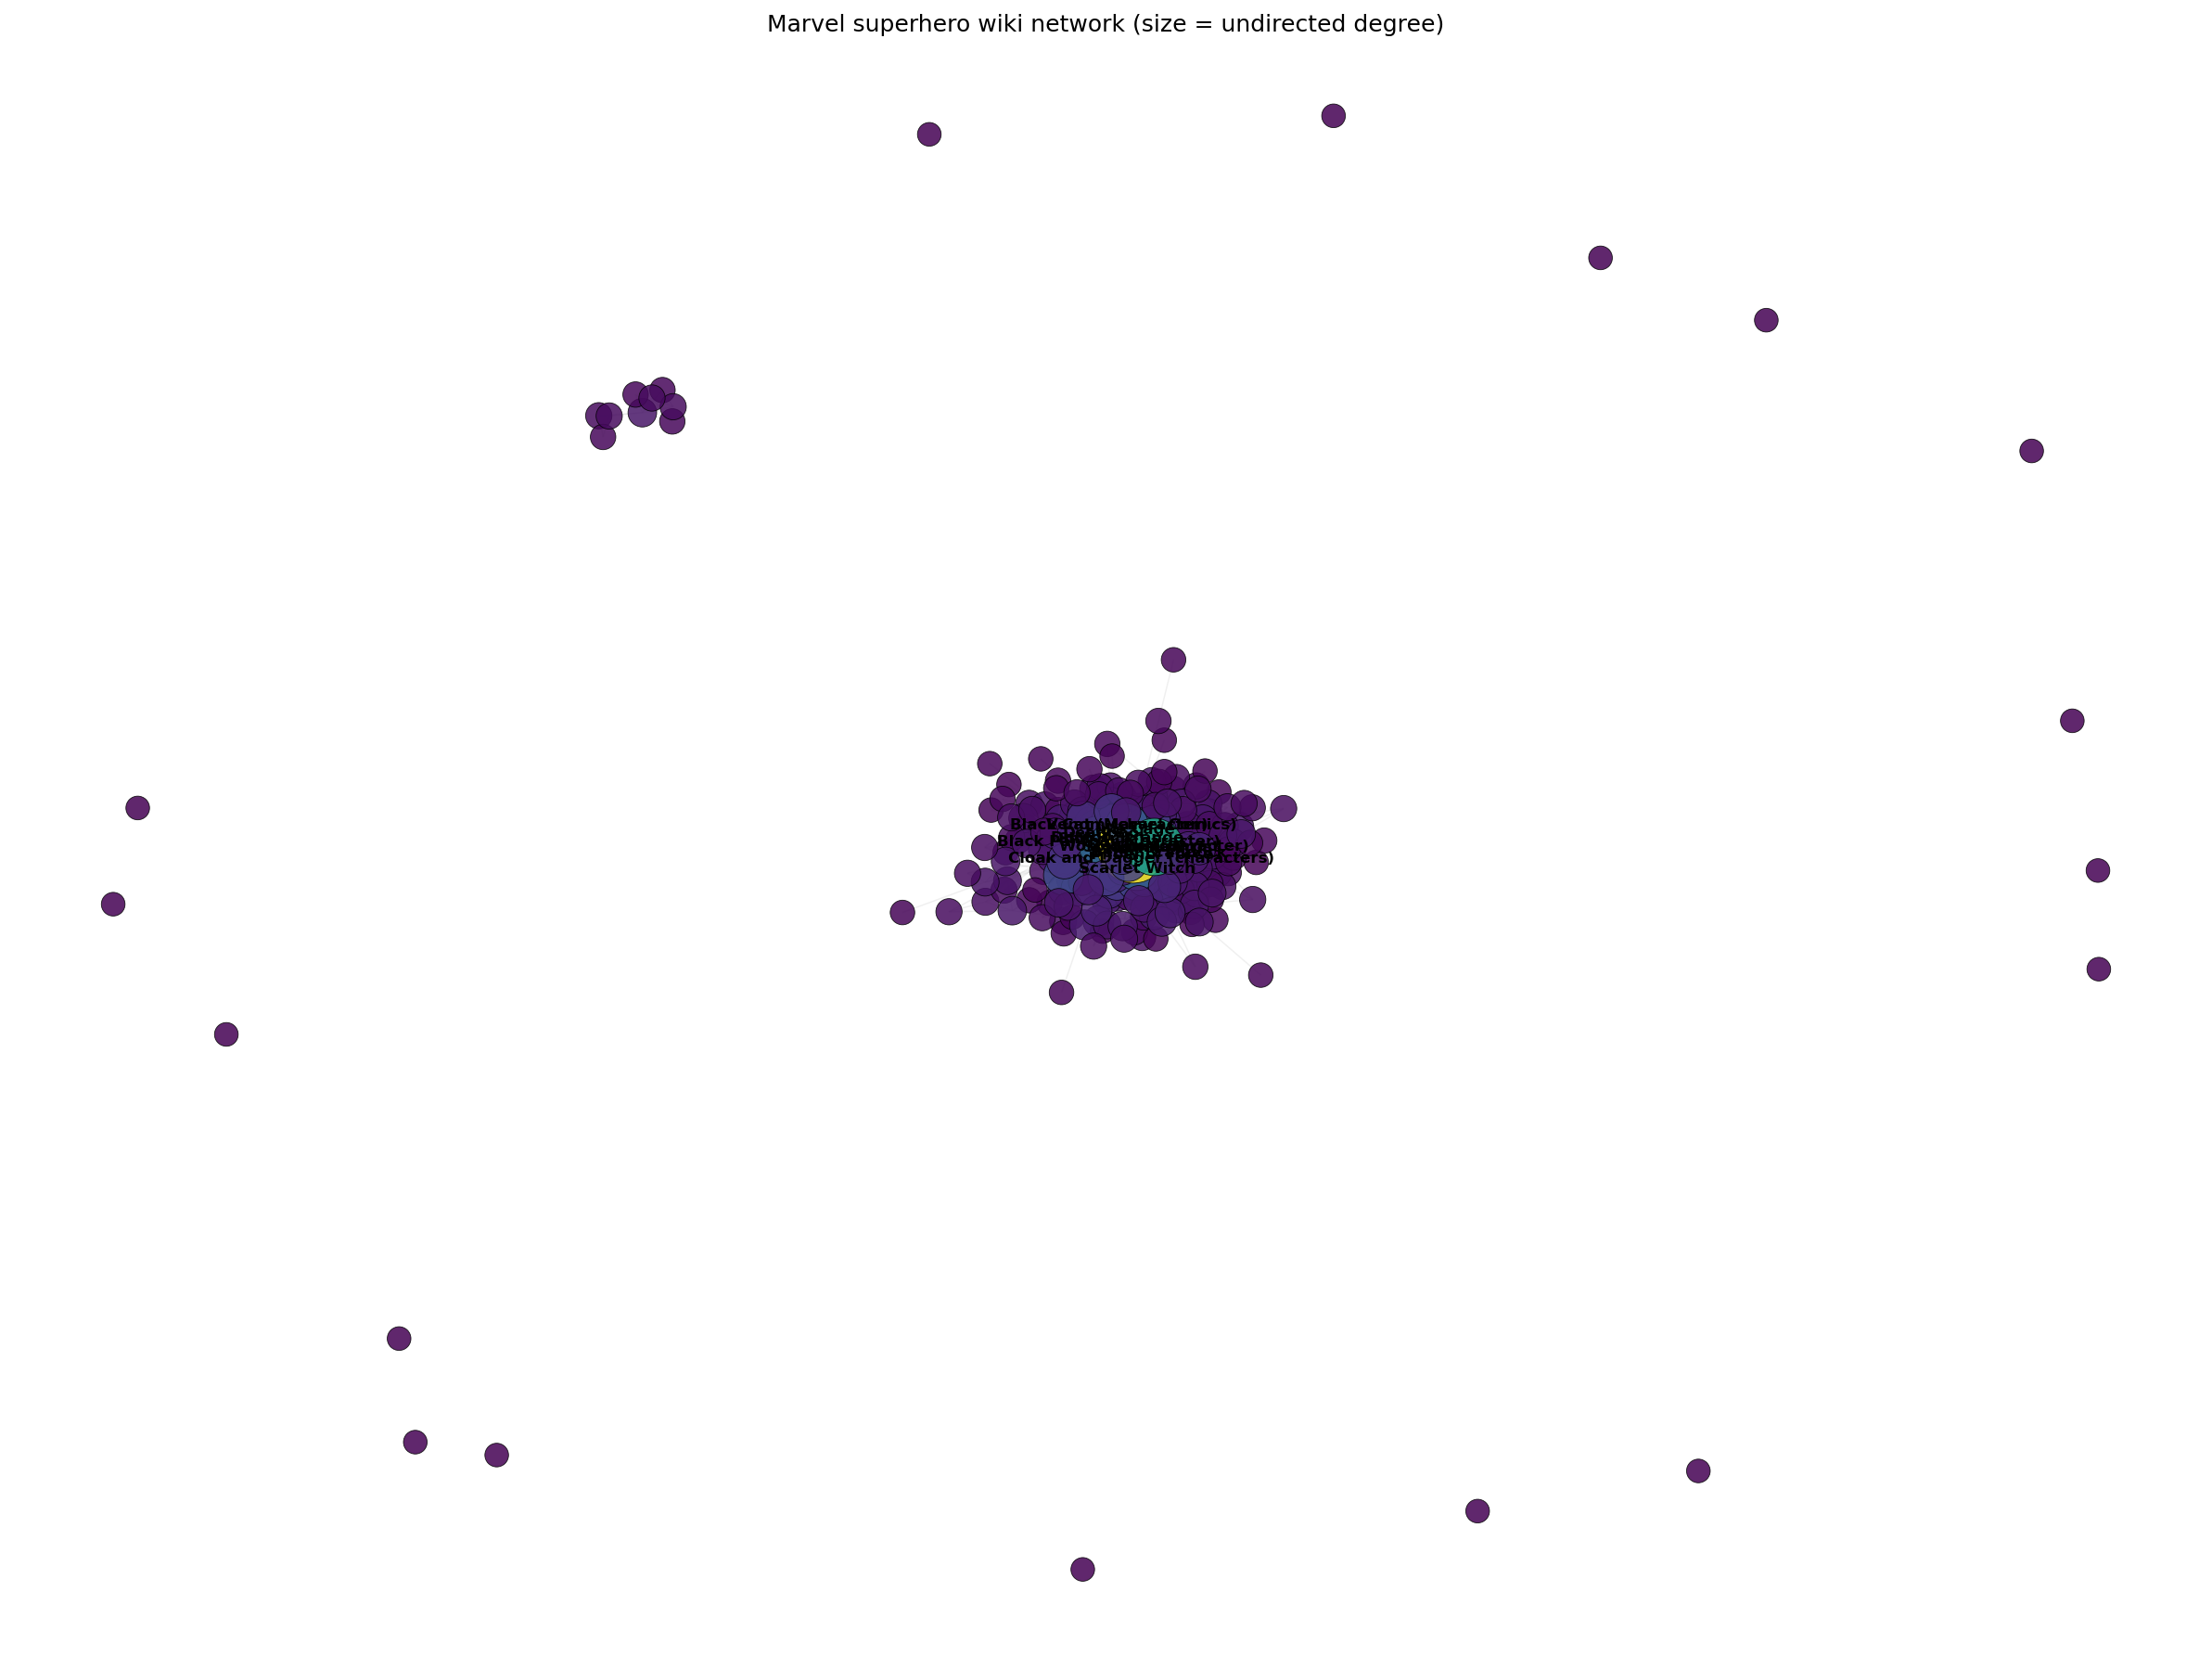

In [10]:
degree_centrality = nx.degree_centrality(G_u)
sizes = [150 + 3500 * degree_centrality[node] for node in G_u.nodes()]
top_nodes = set(node_metrics.nlargest(15, "undirected_degree")["character"])
labels = {node: node.replace("_", " ") for node in top_nodes}

pos = nx.spring_layout(G_u, seed=42)
fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(G_u, pos, edge_color="lightgray", width=0.7, alpha=0.35, ax=ax)
nx.draw_networkx_nodes(
    G_u, pos, node_size=sizes,
    node_color=[degree_centrality[node] for node in G_u.nodes()],
    cmap="viridis", edgecolors="black", linewidths=0.4, alpha=0.85, ax=ax,
)
nx.draw_networkx_labels(G_u, pos, labels=labels, font_size=8, font_weight="bold", ax=ax)
ax.set_axis_off()
ax.set_title("Marvel superhero wiki network (size = undirected degree)")
plt.tight_layout()
plt.show()

## So who is the center of the Marvel Wikipedia universe?

We started with a simple assumption: famous superheroes should sit at the center of the Marvel Wikipedia network. That turns out to be only partly true.

Some characters dominate because many other pages point toward them. Others dominate because they point out to many pages. Some combine both behaviors. Some are peripheral, and a few are effectively absent from this 303-character network.

The key point is that there is no single definition of importance. A character can be central in one sense and peripheral in another. A Wikipedia hyperlink network is not a map of fictional friendship or canonical importance; it is a map of how the wiki itself organizes attention.

In other words, the center of the Marvel universe depends on what kind of center we mean.


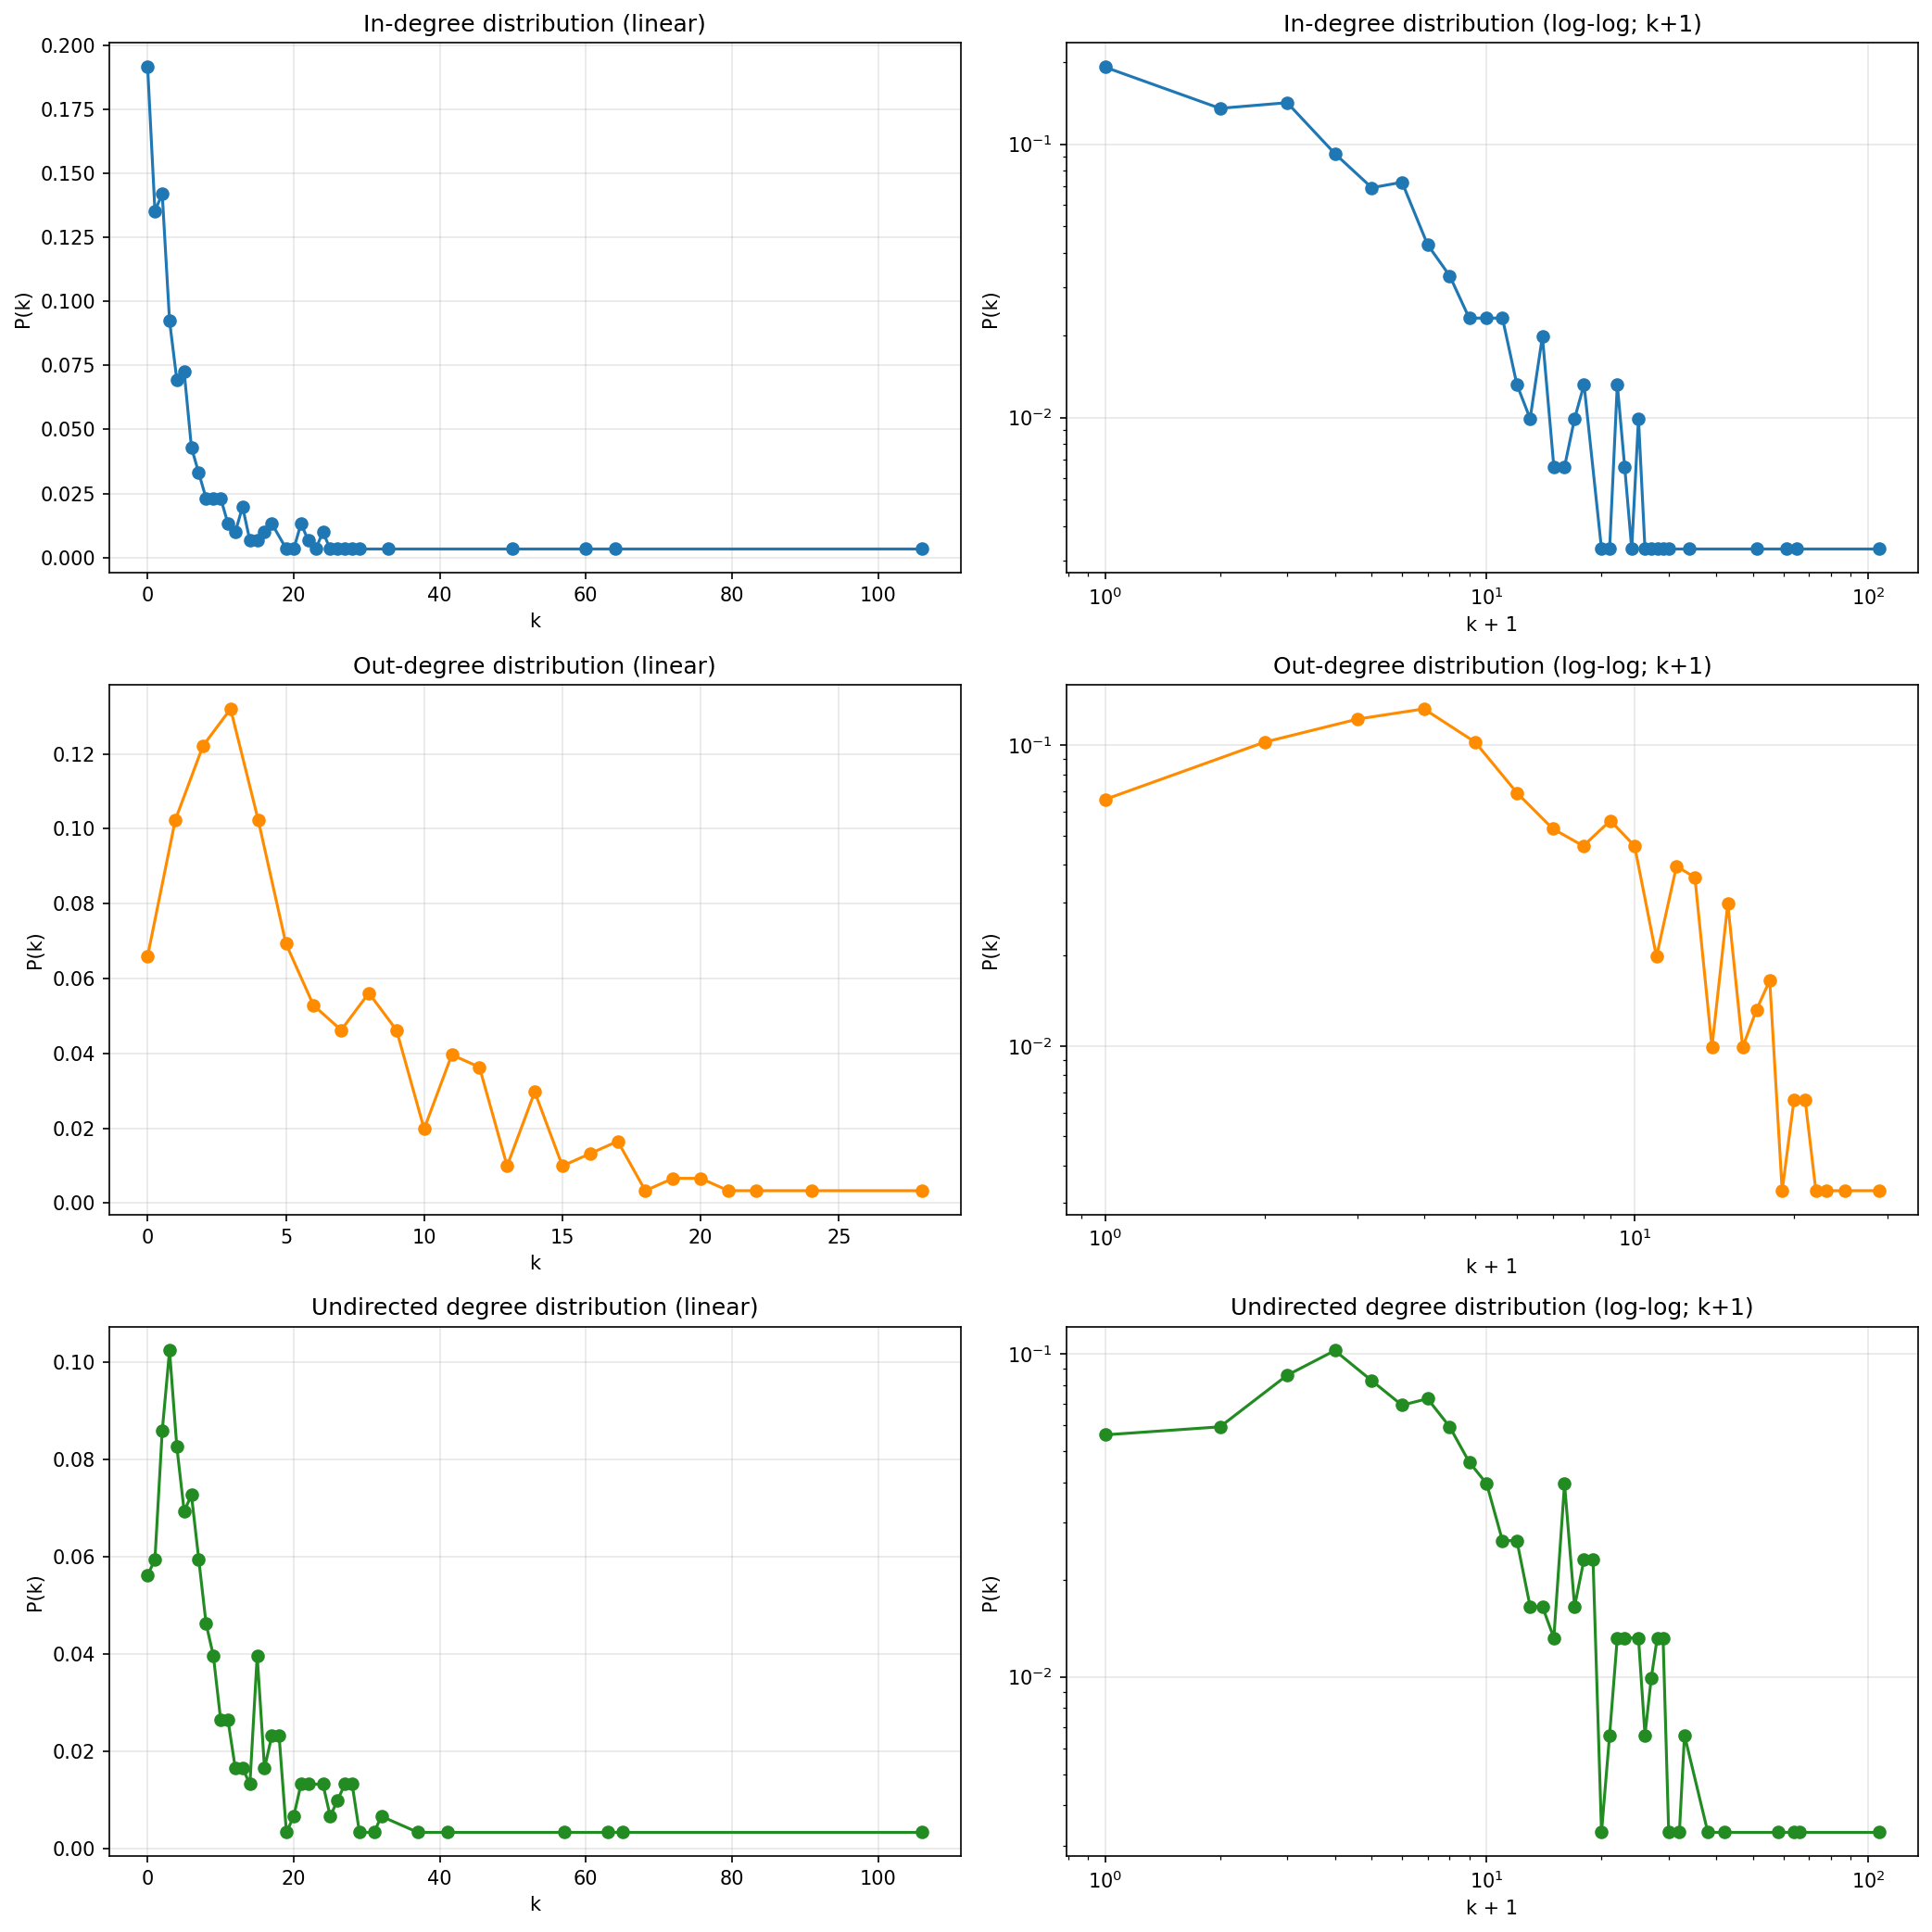

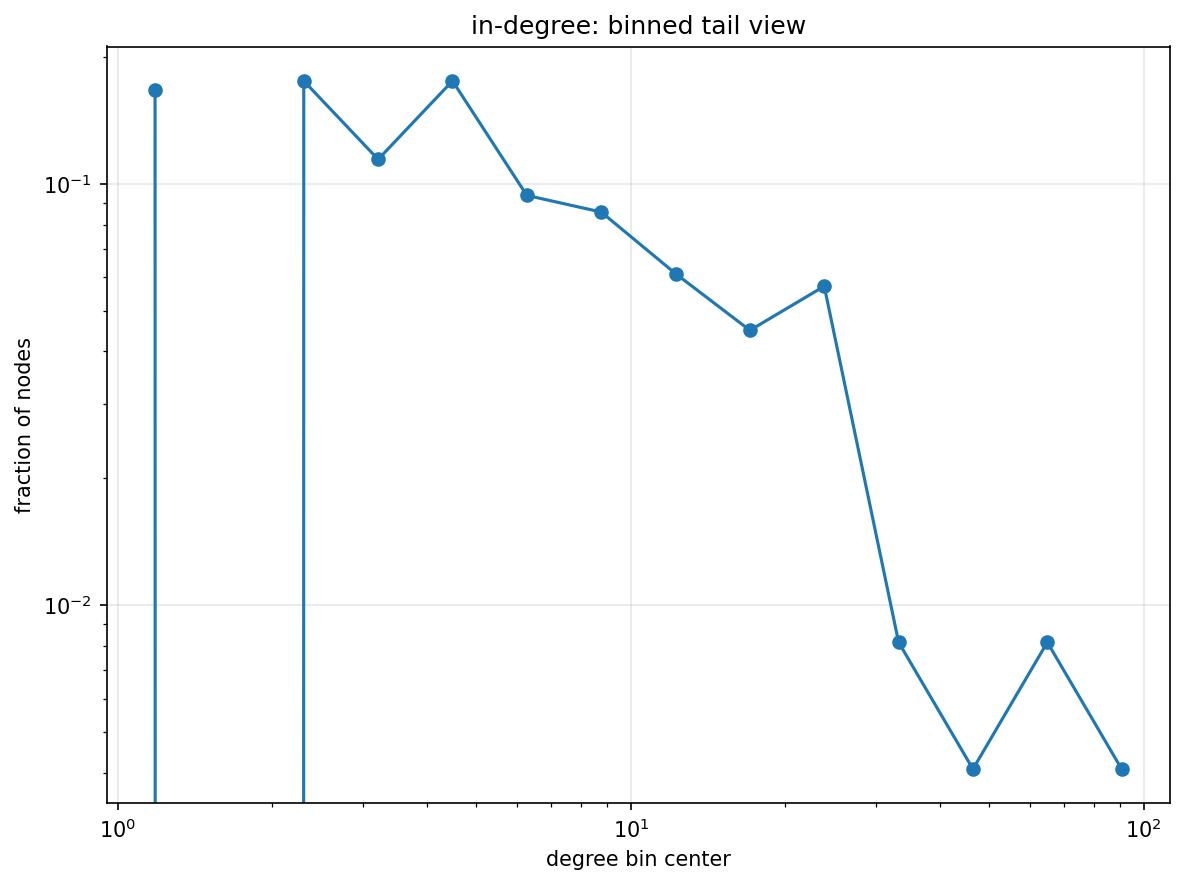

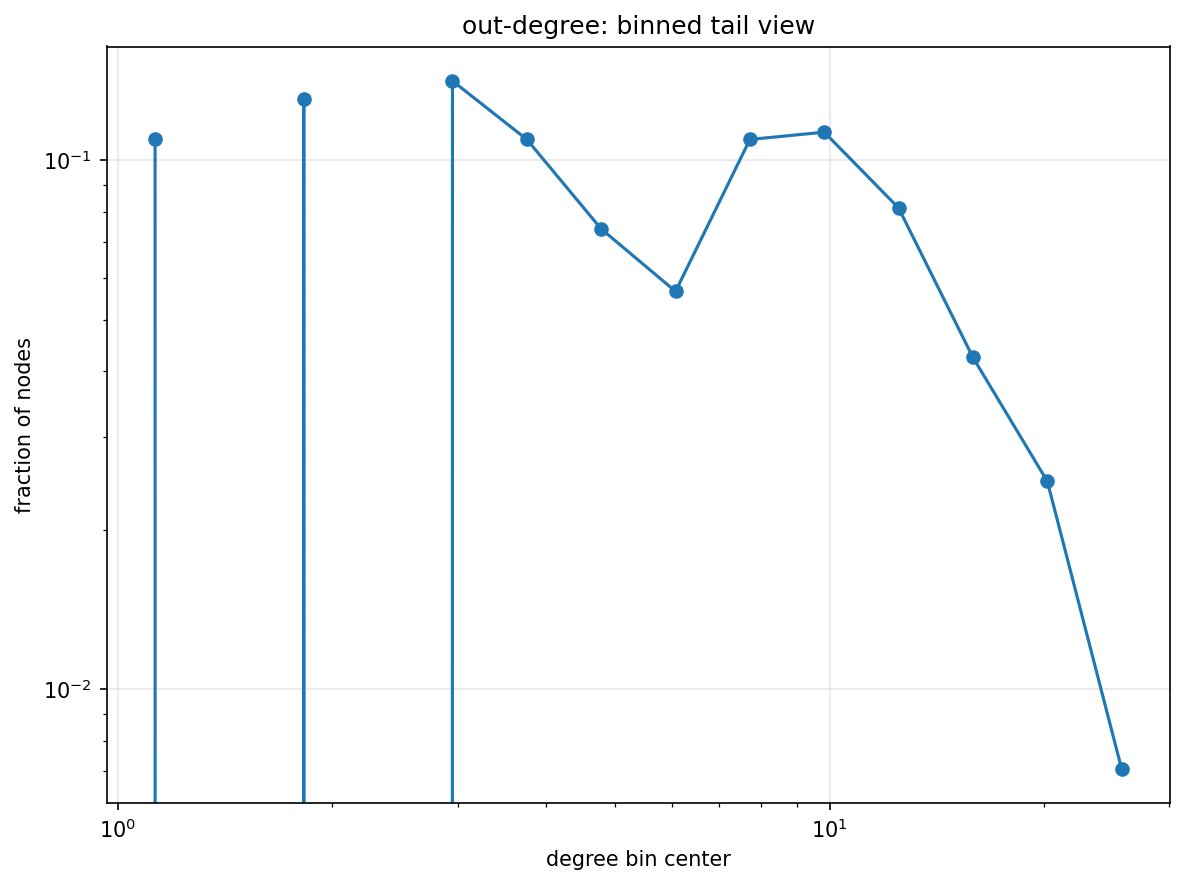

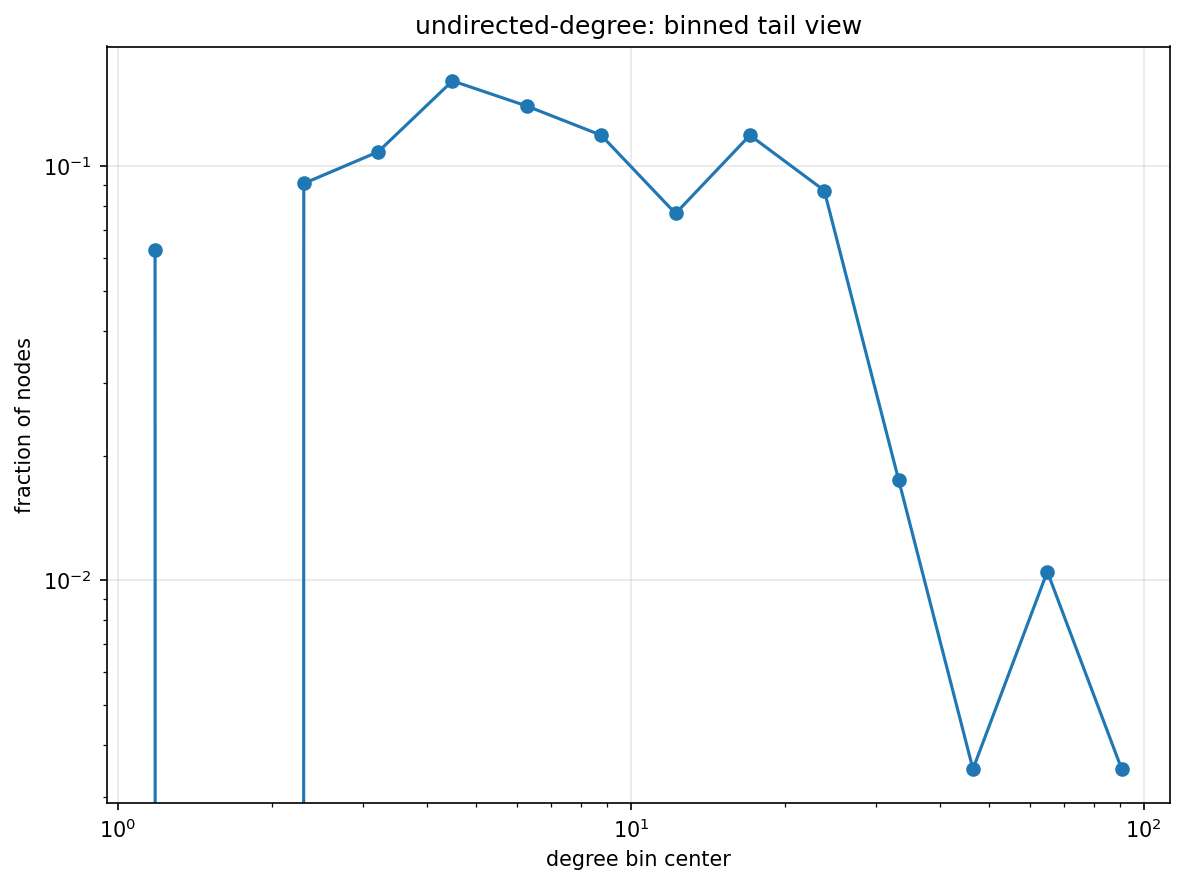

Appendix plots saved to outputs/


In [11]:
# Degree distributions for the appendix
# We use the fraction of nodes P(k) to keep the comparison transparent.

def degree_distribution(degrees):
    counts = Counter(degrees)
    total = sum(counts.values())
    dist = pd.DataFrame({'k': sorted(counts.keys()), 'P_k': [counts[k] / total for k in sorted(counts.keys())]})
    return dist

in_deg = [G.in_degree(n) for n in G.nodes()]
out_deg = [G.out_degree(n) for n in G.nodes()]
und_deg = [G_u.degree(n) for n in G.nodes()]

in_dist = degree_distribution(in_deg)
out_dist = degree_distribution(out_deg)
und_dist = degree_distribution(und_deg)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# linear plots
axes[0, 0].plot(in_dist['k'], in_dist['P_k'], marker='o')
axes[0, 0].set_title('In-degree distribution (linear)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('P(k)')
axes[0, 0].grid(alpha=0.3)

axes[1, 0].plot(out_dist['k'], out_dist['P_k'], marker='o', color='darkorange')
axes[1, 0].set_title('Out-degree distribution (linear)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('P(k)')
axes[1, 0].grid(alpha=0.3)

axes[2, 0].plot(und_dist['k'], und_dist['P_k'], marker='o', color='forestgreen')
axes[2, 0].set_title('Undirected degree distribution (linear)')
axes[2, 0].set_xlabel('k')
axes[2, 0].set_ylabel('P(k)')
axes[2, 0].grid(alpha=0.3)

# log-log plots, handling zero degrees explicitly by plotting k+1 for the x-axis
in_dist_log = degree_distribution([d + 1 for d in in_deg])
out_dist_log = degree_distribution([d + 1 for d in out_deg])
und_dist_log = degree_distribution([d + 1 for d in und_deg])

axes[0, 1].loglog(in_dist_log['k'], in_dist_log['P_k'], marker='o')
axes[0, 1].set_title('In-degree distribution (log-log; k+1)')
axes[0, 1].set_xlabel('k + 1')
axes[0, 1].set_ylabel('P(k)')
axes[0, 1].grid(alpha=0.3)

axes[1, 1].loglog(out_dist_log['k'], out_dist_log['P_k'], marker='o', color='darkorange')
axes[1, 1].set_title('Out-degree distribution (log-log; k+1)')
axes[1, 1].set_xlabel('k + 1')
axes[1, 1].set_ylabel('P(k)')
axes[1, 1].grid(alpha=0.3)

axes[2, 1].loglog(und_dist_log['k'], und_dist_log['P_k'], marker='o', color='forestgreen')
axes[2, 1].set_title('Undirected degree distribution (log-log; k+1)')
axes[2, 1].set_xlabel('k + 1')
axes[2, 1].set_ylabel('P(k)')
axes[2, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Binned versions for the tail
for label, degs in [('in-degree', in_deg), ('out-degree', out_deg), ('undirected-degree', und_deg)]:
    values = np.asarray(degs)
    bins = np.logspace(0, np.log10(max(values) + 1), 15)
    counts, edges = np.histogram(values, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])
    probs = counts / counts.sum()
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(centers, probs, marker='o', linestyle='-')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{label}: binned tail view')
    ax.set_xlabel('degree bin center')
    ax.set_ylabel('fraction of nodes')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(Path('outputs') / f'{label.replace("-", "_")}_binned.png', bbox_inches='tight')
    plt.show()

print('Appendix plots saved to outputs/')


## Interactive D3 visualization

The interactive popularity map is implemented as a web page so that D3.js can handle the hover, search, and selection interactions. Start a local server from the project root before running the next cell:

```bash
python3 -m http.server 8000
```

The server is needed because the page loads its data with JavaScript `fetch()`.

In [12]:
from IPython.display import IFrame

IFrame(
    src="http://localhost:8000/Week1/index.html",
    width="100%",
    height=850,
)